In [1]:
!nvidia-smi

Mon Mar 16 13:14:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.32                 Driver Version: 581.32         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 32%   31C    P8              8W /  170W |     723MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:

import tensorflow as tf
from tensorflow.keras import layers
from glob import glob
import numpy as np
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from keras.optimizers import Adam
from tensorflow.keras.metrics import *

In [29]:


root_dir = r"D:\E0323036-SEM6\dl_med\segmentation\training_set"
paths = glob(os.path.join(root_dir, "**", "*.*"), recursive=True)
print(paths[:5])


['D:\\E0323036-SEM6\\dl_med\\segmentation\\training_set\\training_set\\100_2HC.png', 'D:\\E0323036-SEM6\\dl_med\\segmentation\\training_set\\training_set\\100_2HC_Annotation.png', 'D:\\E0323036-SEM6\\dl_med\\segmentation\\training_set\\training_set\\101_HC.png', 'D:\\E0323036-SEM6\\dl_med\\segmentation\\training_set\\training_set\\101_HC_Annotation.png', 'D:\\E0323036-SEM6\\dl_med\\segmentation\\training_set\\training_set\\102_2HC.png']


In [17]:
import os

VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def load_image(path, size):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    image = cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)
    return image.astype(np.float32) / 255.0

def load_data(root_path, size, max_items=None):
    all_paths = sorted(
        p for p in glob(os.path.join(root_path, "**", "*.*"), recursive=True)
        if os.path.splitext(p)[1].lower() in VALID_EXTS
    )

    mask_map = {}
    image_paths = []
    for path in all_paths:
        name = os.path.basename(path)
        if "_annotation" in name.lower():
            base_name = name.lower().replace("_annotation", "")
            mask_map[base_name] = path
        else:
            image_paths.append(path)

    if max_items is not None:
        image_paths = image_paths[:max_items]

    images = []
    masks = []

    for img_path in image_paths:
        img_name = os.path.basename(img_path).lower()
        mask_path = mask_map.get(img_name)
        if mask_path is None:
            continue

        img = load_image(img_path, size)
        mask = load_image(mask_path, size)
        if img is None or mask is None:
            continue

        images.append(img)
        masks.append((mask > 0.5).astype(np.float32))

    X = np.array(images, dtype=np.float32)
    y = np.array(masks, dtype=np.float32)
    return X, y

In [30]:
size = 256
X, y = load_data(
    root_path='D:\\E0323036-SEM6\\dl_med\\segmentation\\training_set',
    size=size,
    max_items=1900
)
print('X shape:', X.shape, 'dtype:', X.dtype)
print('y shape:', y.shape, 'dtype:', y.dtype)

X shape: (999, 256, 256) dtype: float32
y shape: (999, 256, 256) dtype: float32


In [32]:

def encode(inputs):
 conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
 conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv1)
 pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

 conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(pool1)
 conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv2)
 pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

 conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool2)
 conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3)
 pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

 conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool3)
 conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv4)
 pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)

 conv5 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool4)
 conv5 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv5)
 return conv5, conv4, conv3, conv2, conv1

In [44]:
def decode(conv5, conv4, conv3, conv2, conv1, num_classes):
 up6 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv5)
 crop4 = layers.Cropping2D(4)(conv4)
 concat6 = layers.Concatenate(axis=3)([crop4, up6])
 conv6 = layers.Conv2D(256, 3, activation='relu', padding='same')(concat6)
 conv6 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv6)

 up7 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv6)
 crop3 = layers.Cropping2D(16)(conv3)
 concat7 = layers.Concatenate(axis=3)([crop3, up7])
 conv7 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat7)
 conv7 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv7)

 up8 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv7)
 crop2 = layers.Cropping2D(40)(conv2)
 concat8 = layers.Concatenate(axis=3)([crop2, up8])
 conv8 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat8)
 conv8 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv8)

 up9 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv8)
 crop1 = layers.Cropping2D(80)(conv1)
 concat9 = layers.Concatenate(axis=3)([crop1, up9])
 conv9 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat9)
 conv9 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv9)

 conv10 = layers.Conv2D(num_classes, 1, padding='same')(conv9)
 conv10 = layers.Softmax(axis=-1)(conv10)
 return conv10

In [38]:
def dice_fg(y_true, y_pred, eps=1e-7):
 y_true_f = tf.cast(y_true[..., 1], tf.float32)
 y_pred_f = tf.cast(y_pred[..., 1], tf.float32)
 inter = tf.reduce_sum(y_true_f * y_pred_f)
 denom = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
 return (2.0 * inter + eps) / (denom + eps)

def dice_loss_fg(y_true, y_pred):
 return 1.0 - dice_fg(y_true, y_pred)

def weighted_cce(y_true, y_pred):
 class_weights = tf.constant([0.05, 0.95], dtype=tf.float32)
 y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
 ce = -tf.reduce_sum(y_true * tf.math.log(y_pred) * class_weights, axis=-1)
 return tf.reduce_mean(ce)

def combined_loss(y_true, y_pred):
 return weighted_cce(y_true, y_pred) + dice_loss_fg(y_true, y_pred)

def create_unet(input_size=(256, 256, 1), num_classes=2):
 inputs = layers.Input(input_size)
 conv5, conv4, conv3, conv2, conv1 = encode(inputs)
 conv10 = decode(conv5, conv4, conv3, conv2, conv1, num_classes)
 model = Model(inputs, conv10)
 model.compile(
     optimizer=Adam(learning_rate=3e-4),
     loss=combined_loss,
     metrics=['accuracy', dice_fg]
 )
 return model

model = create_unet(input_size=(size, size, 1), num_classes=2)
model.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_188 (Conv2D)            (None, 256, 256, 32  320         ['input_12[0][0]']               
                                )                                                                 
                                                                                                  
 conv2d_189 (Conv2D)            (None, 256, 256, 32  9248        ['conv2d_188[0][0]']             
                                )                                                           

In [39]:

X_in = X[..., np.newaxis].astype(np.float32)
y_bin = (y > 0.5).astype(np.uint8)
y_in = tf.keras.utils.to_categorical(y_bin, num_classes=2).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_in, y_in, test_size=0.2, random_state=42
)
print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)
print('Foreground ratio in train masks:', float(np.mean(y_train[..., 1])))

model = create_unet(input_size=(size, size, 1), num_classes=2)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_fg', mode='max', patience=3, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_fg', mode='max', factor=0.5, patience=2, min_lr=1e-6
    )
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=2,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Train: (799, 256, 256, 1) (799, 256, 256, 2)
Test : (200, 256, 256, 1) (200, 256, 256, 2)
Foreground ratio in train masks: 0.007413823623210192
Epoch 1/20
400/400 [==============================] - 17s 39ms/step - loss: 0.9161 - accuracy: 0.9561 - dice_fg: 0.1118 - val_loss: 0.8577 - val_accuracy: 0.9768 - val_dice_fg: 0.1679 - lr: 3.0000e-04
Epoch 2/20
400/400 [==============================] - 16s 39ms/step - loss: 0.8261 - accuracy: 0.9744 - dice_fg: 0.1981 - val_loss: 0.8203 - val_accuracy: 0.9756 - val_dice_fg: 0.2044 - lr: 3.0000e-04
Epoch 3/20
400/400 [==============================] - 16s 39ms/step - loss: 0.7991 - accuracy: 0.9764 - dice_fg: 0.2228 - val_loss: 0.7995 - val_accuracy: 0.9728 - val_dice_fg: 0.2230 - lr: 3.0000e-04
Epoch 4/20
400/400 [==============================] - 16s 39ms/step - loss: 0.7939 - accuracy: 0.9764 - dice_fg: 0.2276 - val_loss: 0.7860 - val_accuracy: 0.9754 - val_dice_fg: 0.2334 - lr: 3.0000e-04
Epoch 5/20
400/400 [==============================] 

Final train loss: 0.6173
Final val loss  : 0.7889
Generalization gap (val-train): 0.1717
Mean Dice (test): 0.2515
Mean IoU  (test): 0.1469


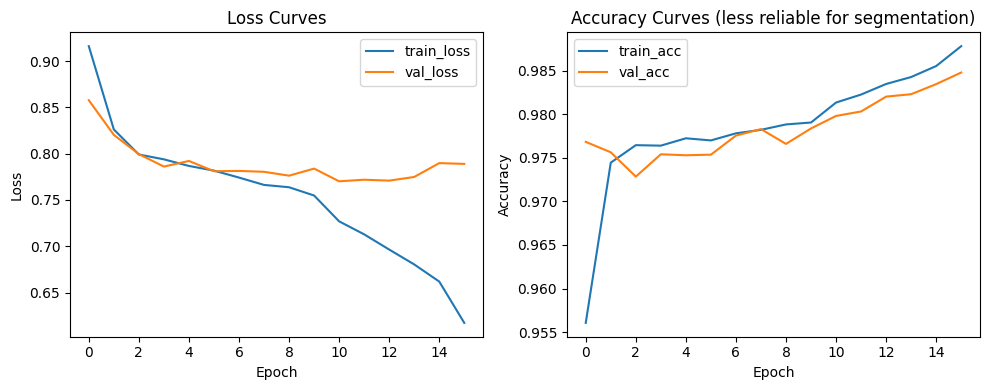

In [41]:

train_loss = history.history['loss']
val_loss = history.history['val_loss']
final_gap = val_loss[-1] - train_loss[-1]
print(f'Final train loss: {train_loss[-1]:.4f}')
print(f'Final val loss  : {val_loss[-1]:.4f}')
print(f'Generalization gap (val-train): {final_gap:.4f}')

y_pred_prob = model.predict(X_test, batch_size=2, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=-1).astype(np.uint8)
y_true = np.argmax(y_test, axis=-1).astype(np.uint8)

def dice_iou_binary(y_true_mask, y_pred_mask, eps=1e-7):
    y_true_f = y_true_mask.reshape(-1).astype(np.float32)
    y_pred_f = y_pred_mask.reshape(-1).astype(np.float32)
    inter = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - inter
    dice = (2.0 * inter + eps) / (np.sum(y_true_f) + np.sum(y_pred_f) + eps)
    iou = (inter + eps) / (union + eps)
    return dice, iou

dice_scores = []
iou_scores = []
for i in range(len(y_true)):
    d, j = dice_iou_binary(y_true[i], y_pred[i])
    dice_scores.append(d)
    iou_scores.append(j)

print(f'Mean Dice (test): {np.mean(dice_scores):.4f}')
print(f'Mean IoU  (test): {np.mean(iou_scores):.4f}')

# Quick visual check of training behavior
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='train_loss')
plt.plot(val_loss, label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curves (less reliable for segmentation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

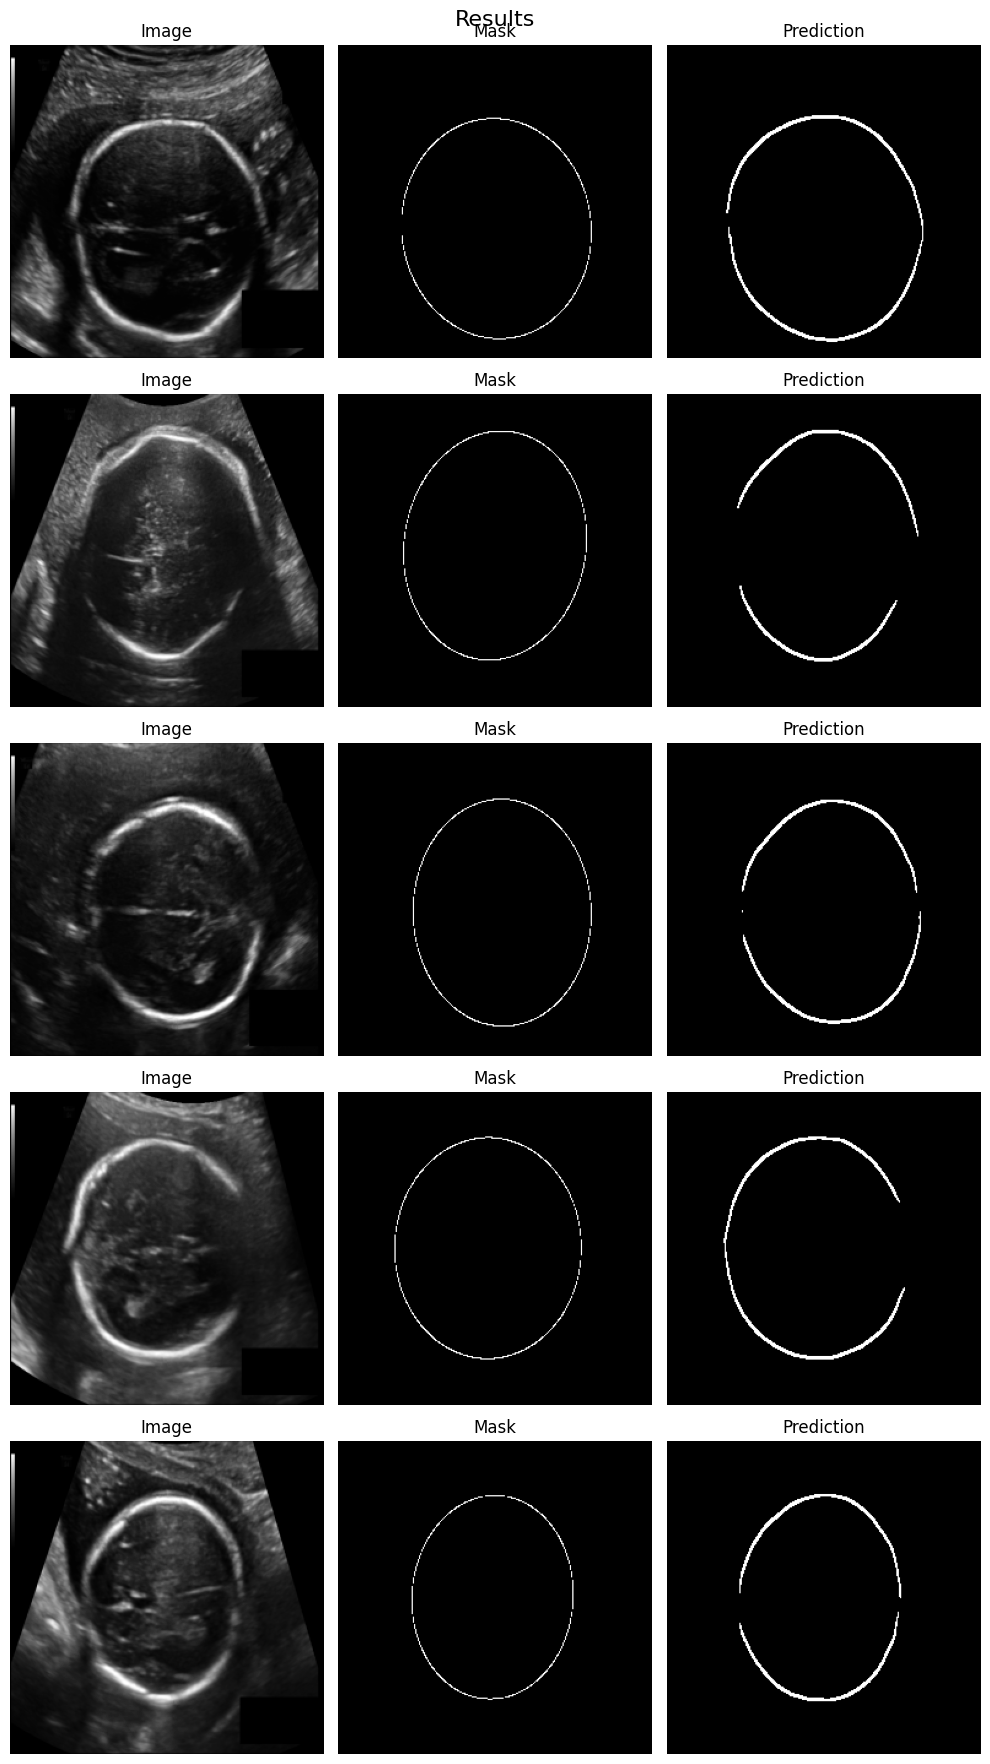

In [43]:
fig, ax = plt.subplots(5, 3, figsize=(10, 18))

j = np.random.randint(0, X_test.shape[0], 5)
for i in range(5):
    idx = j[i]
    img = X_test[idx].squeeze()
    true_mask = np.argmax(y_test[idx], axis=-1)
    pred_prob = model.predict(np.expand_dims(X_test[idx], 0), verbose=0)[0]
    pred_mask = np.argmax(pred_prob, axis=-1)

    ax[i, 0].imshow(img, cmap='gray')
    ax[i, 0].set_title('Image')
    ax[i, 1].imshow(true_mask, cmap='gray')
    ax[i, 1].set_title('Mask')
    ax[i, 2].imshow(pred_mask, cmap='gray')
    ax[i, 2].set_title('Prediction')

    for k in range(3):
        ax[i, k].axis('off')

fig.suptitle('Results', fontsize=16)
plt.tight_layout()
plt.show()

In [46]:
print(f'\033[93m')
y_pred=model.predict(X_test,verbose=0)
y_pred_thresholded = y_pred > 0.5
IOU_keras = MeanIoU(num_classes=2)
IOU_keras.update_state(y_pred_thresholded, y_test)
print("Mean IoU =", IOU_keras.result().numpy())

prec_score = Precision()
prec_score.update_state(y_pred_thresholded, y_test)
p = prec_score.result().numpy()
print('Precision Score = %.3f' % p)

recall_score = Recall()
recall_score.update_state(y_pred_thresholded, y_test)
r = recall_score.result().numpy()
print('Recall Score = %.3f' % r)

f1_score = 2*(p*r)/(p+r)
print('F1 Score = %.3f' % f1_score)


Mean IoU = 0.9646671
Precision Score = 0.982
Recall Score = 0.982
F1 Score = 0.982
